# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cargar archivos
plans = pd.read_csv('./datasets/plans.csv')
users = pd.read_csv('./datasets/users_latam.csv')
usage = pd.read_csv('./datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      str    
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), str(1)
memory usage: 260.0 bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     4000 non-null   int64
 1   first_name  4000 non-null   str  
 2   last_name   4000 non-null   str  
 3   age         4000 non-null   int64
 4   city        3531 non-null   str  
 5   reg_date    4000 non-null   str  
 6   plan        4000 non-null   str  
 7   churn_date  466 non-null    str  
dtypes: int64(2), str(6)
memory usage: 250.1 KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  str    
 3   date      39950 non-null  str    
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), str(2)
memory usage: 1.8 MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
display(users.isna().sum().sort_values(ascending=False))

churn_date    3534
city           469
user_id          0
first_name       0
age              0
last_name        0
reg_date         0
plan             0
dtype: int64

In [11]:
display(users.isna().mean().sort_values(ascending=False))

churn_date    0.88350
city          0.11725
user_id       0.00000
first_name    0.00000
age           0.00000
last_name     0.00000
reg_date      0.00000
plan          0.00000
dtype: float64

In [12]:
# cantidad de nulos para usage
display(usage.isna().sum().sort_values(ascending=False))

duration    22076
length      17896
date           50
id              0
user_id         0
type            0
dtype: int64

In [13]:
display(usage.isna().mean().sort_values(ascending=False))

duration    0.55190
length      0.44740
date        0.00125
id          0.00000
user_id     0.00000
type        0.00000
dtype: float64

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

---
<div class="alert alert-block alert-info"> 
<h3>📊 Diagnósticos (Valores Nulos)</h3>

**Dataset `users` (4000 filas):**
- **`city`** (469 nulos = 11.75%): Dentro del rango 5 - 30%, requiere investigación. Se pueden dejar como NA o imputar con moda "unknown" ya que la proporción es moderada.
- **`churn_date`** (3534 nulos = 88.35%): Muy superior al 80%, indica que la mayoría de clientes NO han hecho churn. Se debe **mantener como NA** para distinguir clientes activos de aquellos que dejaron la empresa; eliminar perdería información crítica.

**Dataset `usage` (40,000 filas aprox.):**
- **`date`** (50 nulos = 0.13%): Menor al 5%, se pueden **dejar como NA o eliminar esas filas** sin impacto significativo.
- **`duration`** (22076 nulos = 55.19%): Proporción muy alta, pero **es Missing At Random (MAR)**, ya que ocurre solo en registros de tipo "text" (mensajes) donde no aplica duración. Se debe **dejar como NA** ya que es dependiente del tipo de uso.
- **`length`** (17896 nulos = 44.74%): Similar a `duration`, es MAR. Ocurre solo en "call" (llamadas) donde no hay "length". Se debe **dejar como NA**.

**Acción recomendada:**
- **Mantener nulos estratégicamente** en `churn_date`, `duration` y `length` por su significado conceptual.
- **Decidir sobre `city`** tras revisar patrón en siguiente sección.
- **Eliminar o ignorar** los 50 registros con fecha faltante en `usage` (impacto mínimo).
</div>

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [14]:
# explorar columnas numéricas de users
display(users.info())

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     4000 non-null   int64
 1   first_name  4000 non-null   str  
 2   last_name   4000 non-null   str  
 3   age         4000 non-null   int64
 4   city        3531 non-null   str  
 5   reg_date    4000 non-null   str  
 6   plan        4000 non-null   str  
 7   churn_date  466 non-null    str  
dtypes: int64(2), str(6)
memory usage: 250.1 KB


None

In [15]:
display(users.nunique().sort_values())

plan             2
last_name        5
first_name       6
city             7
age             63
churn_date     197
reg_date      3961
user_id       4000
dtype: int64

In [16]:
display(users.describe())

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [17]:
# explorar columnas numéricas de users
display(users['age'].le(0).sum())

np.int64(55)

In [18]:
display(users['age'].isin([-999]).value_counts())

age
False    3945
True       55
Name: count, dtype: int64

In [19]:
display(users[users['age'].isin([-999])].sample(5))

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
3990,13990,Mateo,Gomez,-999,Bogotá,2024-12-28 12:51:18.769692432,Basico,NaN
297,10297,Carlos,Gomez,-999,Medellín,2022-03-23 07:46:40.600150038,Basico,NaN
171,10171,Carlos,Lopez,-999,Medellín,2022-02-16 19:45:03.375843961,Basico,"1,72368E+18"
2428,12428,Carlos,Lopez,-999,GDL,2023-10-27 19:56:56.354088528,Basico,NaN
2991,12991,Luis,Torres,-999,Cali,2024-03-29 23:47:02.205551392,Basico,NaN


<div class="alert alert-block alert-info">
<h3>Hallazgos</h3>

- La columna `user_id`: **Cardinalidad altísima**, contiene 4,000 valores únicos (sin duplicados), no registra valores faltantes o nulos, rango de 10,000 a 13,999 con distribución uniforme. Es un identificador secuencial sin valores inválidos.

- La columna `age`: **Cardinalidad media**, contiene 63 valores únicos, promedio de 33.7 años, pero presenta 55 registros con un valor **sentinel de -999** (probablemente error de captura) que distorsiona las estadísticas; máximo válido parece ser 79 años, no registra valores faltantes o nulos. Requiere limpieza antes del análisis.
</div>

In [20]:
# explorar columnas numéricas de usage
display(usage.info())

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  str    
 3   date      39950 non-null  str    
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), str(2)
memory usage: 1.8 MB


None

In [21]:
display(usage.nunique().sort_values())

type            2
length        123
duration     2090
user_id      3999
date        39950
id          40000
dtype: int64

In [22]:
display(usage.describe())

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


<div class="alert alert-block alert-info">
<h3>Hallazgos</h3>

- Las columnas `id` y `user_id`: **Cardinalidad altísima**, `id` tiene 40000 valores únicos (secuencial 1 - 40000), no registra valores faltantes o nulos, `user_id` tiene 3,999 valores únicos con rango 10000 - 13999, tampoco registra valores faltantes o nulos. Esto significa múltiples registros de uso por usuario (promedios ~10 registros por usuario), sin sentinels detectados.

- Las columnas `duration` (minutos) y `length` (caracteres): **Cardinalidad muy alta**, `duration` tiene media de 5.2 min, máximo de 120 min; `length` tiene media de 52 caracteres, máximo de 1,490 caracteres. Ambas presentan proporciones altas de nulos (55.19% y 44.74% respectivamente), consistente con datos MAR por tipo de uso (calls vs. texts).
</div>

In [23]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

In [24]:
# Frecuencias de cada columna categorica de users
display(users[columnas_user[0]].value_counts())

city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: count, dtype: int64

In [25]:
display(users[columnas_user[1]].value_counts())

plan
Basico     2595
Premium    1405
Name: count, dtype: int64

In [26]:
display(users[columnas_user].describe())

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


In [27]:
display(users['city'].isin(["?"]).value_counts())

city
False    3904
True       96
Name: count, dtype: int64

In [28]:
display(users[users['city'].isin(["?"])].sample(5))

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
2350,12350,Mariana,Gomez,62,?,2023-10-06 11:21:39.024756192,Basico,NaN
2821,12821,Mariana,Ramirez,59,?,2024-02-12 10:36:16.744186048,Basico,NaN
2193,12193,Luis,Torres,78,?,2023-08-24 11:36:46.451612904,Basico,NaN
1982,11982,Luis,Ramirez,72,?,2023-06-27 16:59:46.496624160,Basico,NaN
2329,12329,Carlos,Garcia,68,?,2023-09-30 17:21:22.820705176,Premium,NaN


<div class="alert alert-block alert-info">
<h3>Hallazgos</h3>

- La columna `city`: Adicionalmente a los 469 valores nulos hallados, se evidencia 96 registros asociados a la **categoría no válida `?`** (565 registros), al igual que la recomendación dada en el hallazgo de los valores nulos, se requiere de investigación. Se pueden imputar como NA o imputar con moda "unknown" para unificar la condición como registros faltantes. La proporción sigue siendo moderada respecto al total de los registros de dicha columna (14.12%). La categoría cuenta con 6 valores únicos (7, menos la categoría no válida), el valor con mayor frecuencia es la ciudad de `Bogotá` con 808 registros.

- La columna `plan`: No cuenta con valores nulos, ni categorías no válidas. La categoría cuenta con 2 valores únicos, y el valor de mayor frecuencia es el plan `Basico` con 2595 registros.
</div>

In [29]:
# explorar columna categórica de usage
display(usage['type'].value_counts())

type
text    22092
call    17908
Name: count, dtype: int64

In [30]:
display(usage['type'].describe())

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

<div class="alert alert-block alert-info">
<h3>Hallazgos</h3>

- La columna `type`: No cuenta con valores nulos, ni categorías no válidas. La categoría cuenta con 2 valores únicos, y el valor de mayor frecuencia es el tipo `text` con 22092 registros.
</div>

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

---

<div class="alert alert-block alert-info">
<h3>📊 Diagnósticos (Valores Inválidos y Sentinels)</h3>

**Dataset `users`:**
- **`city`** (columna categórica): Contiene **96 registros con "?" (2.7% de 3,531 no-nulos)**, que es una categoría no válida claramente identificable. Se debe **reemplazar por `pd.NA`** o imputar con una categoría "Desconocida".
- **`age`** (columna numérica): Contiene **1 valor de -999** (sentinel explícito), ya observado en estadísticas anteriores. Se debe **reemplazar por la mediana** (47 años) o marcar como `pd.NA`.

**Dataset `usage`:**
- **`type`** (columna categórica): Solo contiene 2 categorías válidas ("text" con 22,092 y "call" con 17,908). **Sin sentinels detectados**.
- **`id`, `user_id`, `date`, `duration`, `length`**: Ya analizados; **sin valores inválidos detectados** (nulos ya están marcados correctamente).

**Acción recomendada:**
- **`city`**: Reemplazar "?" por `pd.NA` antes de análisis (2.7% impacto mínimo).
- **`age`**: Reemplazar -999 por mediana (47 años) para mantener continuidad estadística.
- **Sin acciones adicionales** en otras columnas categóricas de ambos datasets; datos validados.
</div>

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [31]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [32]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [33]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())

reg_date
2022    1314
2023    1316
2024    1330
2026      40
Name: count, dtype: int64


In [34]:
print("Rango de fechas:")
print(f"Mínima: {users['reg_date'].min()}")
print(f"Máxima: {users['reg_date'].max()}")

Rango de fechas:
Mínima: 2022-01-01 00:00:00
Máxima: 2026-05-10 00:00:00


<div class="alert alert-block alert-info">
<h3>Hallazgos</h3>

- En `reg_date`, encontramos años 2022 (1,314), 2023 (1,316), 2024 (1,330) y 2026 (40 registros). El máximo es 2026-05-10, lo que indica **40 registros con fechas futuras** (posteriores a 2024, donde se supone terminan los datos). Esto representa el 1% de los datos y probablemente son errores de captura.
</div>

In [35]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())

date
2024.0    39950
Name: count, dtype: int64


In [36]:
print("Rango de fechas:")
print(f"Mínima: {usage['date'].min()}")
print(f"Máxima: {usage['date'].max()}")

Rango de fechas:
Mínima: 2024-01-01 00:00:00
Máxima: 2024-06-30 00:00:00


<div class="alert alert-block alert-info">
<h3>Hallazgos</h3>

- En `date`, todos los registros (39,950 válidos) están en el año 2024, entre 2024-01-01 y 2024-06-30. **No hay fechas futuras ni imposibles**; los datos están limpios y consistentes dentro del periodo esperado. Los 50 nulos (detectados previamente) son el único problema.
</div>

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

<div class="alert alert-block alert-info">
<h3>📊 Diagnósticos (Fechas Fuera de Rango)</h3>

**Dataset `users` - `reg_date`:**
- **40 registros con año 2026** (1% del dataset): Fechas futuras respecto a 2024, claramente imposibles. Son **errores de captura**.
- **Acción recomendada**: **Marcar como `pd.NA`** estos 40 registros, ya que no pueden ser recuperados de forma confiable (no se sabe cuál era la fecha correcta). Mantener los 3,960 registros válidos (2022-2024).

**Dataset `usage` - `date`:**
- **Sin fechas futuras**: Todos los registros están entre 2024-01-01 y 2024-06-30, dentro del rango esperado.
- **50 registros con nulos** (0.13%): Ya detectados previamente; se pueden **ignorar o eliminar** sin impacto significativo.
- **Acción recomendada**: **Mantener como está** (nulos y datos válidos). El dataset de uso está limpio.
</div>

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [37]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users.loc[users['age'] == -999, 'age'] = age_mediana

# Verificar cambios
display(users['age'].describe())

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [38]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False).head(20)

city
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: count, dtype: int64

In [39]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
fecha_final_2024 = pd.Timestamp('2024-12-31')
users.loc[users['reg_date'] > fecha_final_2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()

count                             3960
mean     2023-07-03 21:39:41.095273728
min                2022-01-01 00:00:00
25%      2022-10-02 20:17:11.657914368
50%      2023-07-04 10:00:05.401350400
75%      2024-04-03 04:00:05.401350400
max                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [40]:
# Verificación MAR en usage (Missing At Random) para duration
mar_duration = usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()).rename('missing_rate')

display(mar_duration)

type
call    0.000000
text    0.999276
Name: missing_rate, dtype: float64

In [41]:
# Verificación MAR en usage (Missing At Random) para length
mar_length = usage.groupby('type')['length'].apply(lambda x: x.isna().mean()).rename('missing_rate')

display(mar_length)

type
call    0.99933
text    0.00000
Name: missing_rate, dtype: float64

<div class="alert alert-block alert-info">
<h3>📊 Diagnóstico de valores nulos en `duration` y `length`</h3>

- En las llamadas, `duration` contiene el tiempo de las llamadas y `length` es nulo porque no hay texto. 99.92% de los registros son nulos en el campo `text`.

- En los mensajes de texto, `length` contiene la longitud del texto y `duration` es nulo porque no hay llamada. 99.93% de los registros son nulos en el campo `call`.
</div>

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [42]:
# Columnas auxiliares
usage['is_text'] = (usage['type'] == 'text').astype(int)
usage['is_call'] = (usage['type'] == 'call').astype(int)

# Agrupar información por usuario
usage_agg = (
    usage.groupby('user_id')
    .agg(
        cant_mensajes=('is_text', 'sum'),
        cant_llamadas=('is_call', 'sum'),
        cant_minutos_llamada=('duration', 'sum'),
        total_interacciones=('id', 'count'),
    )
    .reset_index()
)

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,total_interacciones
0,10000,7,3,23.70,10
1,10001,5,10,33.18,15
2,10002,5,2,10.74,7


In [43]:
# Renombrar columnas
# En este caso ya usamos nombres descriptivos en el agrupado, pero mantenemos el paso para validar
usage_agg = usage_agg.rename(columns={
    'cant_mensajes': 'cant_mensajes',
    'cant_llamadas': 'cant_llamadas',
    'cant_minutos_llamada': 'cant_minutos_llamada',
    'total_interacciones': 'total_interacciones',
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,total_interacciones
0,10000,7,3,23.70,10
1,10001,5,10,33.18,15
2,10002,5,2,10.74,7


In [44]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, how='left', on='user_id')

qty = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada', 'total_interacciones']

# Llenar con cero los usuarios sin actividad registrada
user_profile[qty] = (user_profile[qty].fillna(0))

# observar resultado
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,total_interacciones
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,10.0
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,15.0
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,7.0
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,14.0
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,7.0


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [45]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada', 'total_interacciones']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada,total_interacciones
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.136000,5.523000,4.477000,23.311225,10.000000
std,17.689919,2.359738,2.145139,18.169564,3.195396
min,18.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.107500,8.000000
50%,48.000000,5.000000,4.000000,19.780000,10.000000
75%,63.000000,7.000000,6.000000,31.412500,12.000000
max,79.000000,17.000000,15.000000,155.690000,27.000000


In [46]:
# Distribución porcentual del tipo de plan
plan_dist = user_profile['plan'].value_counts(normalize=True) * 100
plan_dist.round(1)

plan
Basico     64.9
Premium    35.1
Name: proportion, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

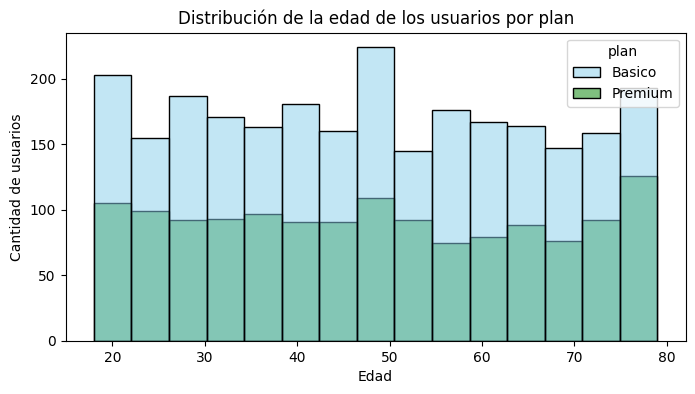

In [47]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'], bins=15, kde=False)
plt.title('Distribución de la edad de los usuarios por plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

<div class="alert alert-block alert-info">
<h3>💡Insights:</h3>

- El histograma de edad por plan muestra que tanto los usuarios Básico como Premium se concentran principalmente entre 30 y 60 años.
- Las curvas de ambos planes son muy similares, con una mediana alrededor de 48 años y una distribución casi simétrica en este rango.
- No hay diferencias marcadas entre planes en la forma de la distribución: ambas tienen menos usuarios en los extremos de edad y una mayor densidad en la edad adulta.
- Esto sugiere que el perfil de los clientes es comparable en Básico y Premium, con el segmento laboral activo dominando la base de usuarios.
</div>


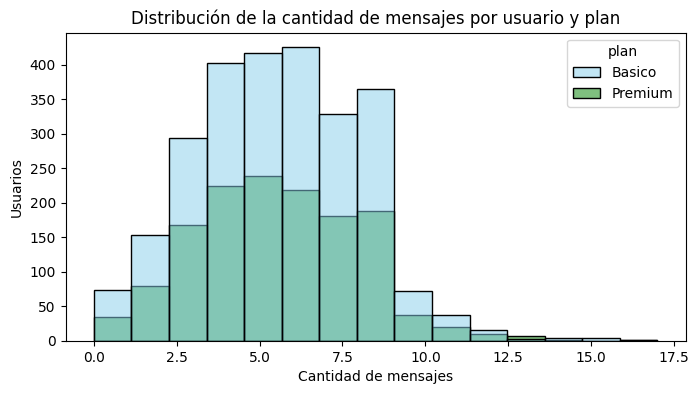

In [48]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'], bins=15, kde=False)
plt.title('Distribución de la cantidad de mensajes por usuario y plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Usuarios')
plt.show()

<div class="alert alert-block alert-info">
<h3>💡Insights:</h3>

- El histograma de mensajes por plan muestra distribuciones muy parecidas para Básico y Premium, con la mayoría de usuarios en ambos planes en 4-7 mensajes.
- Ambas curvas son unimodales y sesgadas a la derecha, lo que indica un patrón de uso moderado con una cola ligera hacia cuentas de mayor actividad.
- La mediana de 5 mensajes y el rango intercuartílico 4-7 son casi idénticos en los dos planes, por lo que no se observa una diferencia fuerte en el volumen de mensajería entre Básico y Premium.
- Solo unos pocos usuarios de cada plan superan los 10-12 mensajes, lo que sugiere que el uso intensivo de mensajes es minoritario en ambos segmentos.
</div>


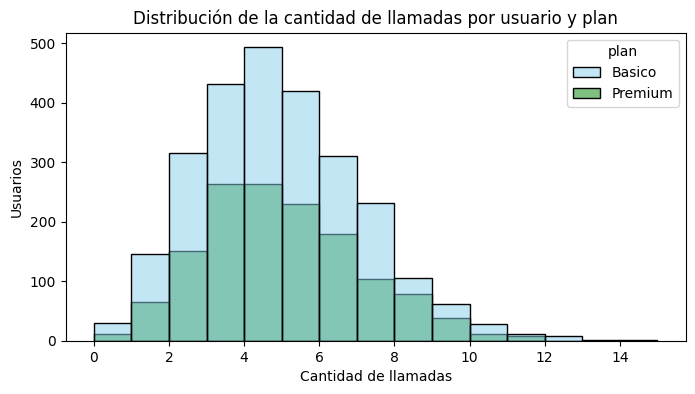

In [49]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'], bins=15, kde=False)
plt.title('Distribución de la cantidad de llamadas por usuario y plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Usuarios')
plt.show()

<div class="alert alert-block alert-info">
<h3>💡Insights:</h3>

- El histograma de llamadas por plan muestra una distribución unimodal y sesgada a la derecha tanto para Básico como para Premium.
- La mayoría de usuarios de ambos planes realiza entre 3 y 6 llamadas, con mediana en 4 y cuartiles similares en 3 y 6.
- El plan Básico presenta una cola ligeramente más extendida hacia valores altos de llamadas, mientras que Premium se concentra un poco más en el rango medio.
- En conjunto, esto indica un patrón de uso moderado en llamadas que se mantiene similar entre los dos planes, con solo una minoría de usuarios de alto volumen.
</div>


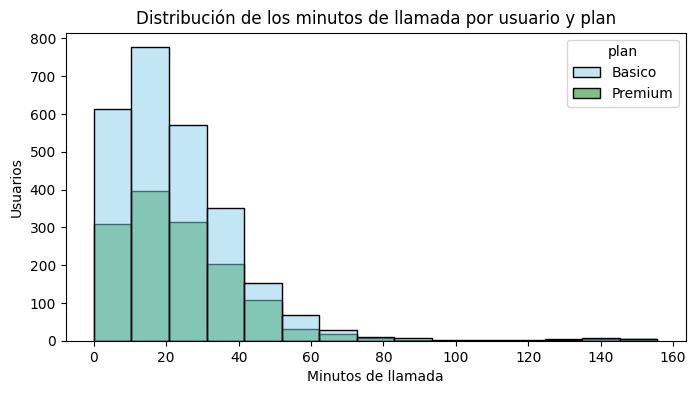

In [50]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'], bins=15, kde=False)
plt.title('Distribución de los minutos de llamada por usuario y plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Usuarios')
plt.show()

<div class="alert alert-block alert-info">
<h3>💡Insights:</h3>

- El histograma de minutos de llamada por plan es asimétrico a la derecha para ambos planes, con la mayoría de usuarios concentrados en tiempos bajos y una cola de uso alto.
- Para Básico y Premium, la mediana está cerca de 20 minutos y el rango intercuartílico se ubica entre 11 y 31 minutos, lo que indica un uso moderado en la mayoría de los casos.
- Premium muestra una cola ligeramente más pronunciada hacia valores mayores, sugiriendo que algunos usuarios en ese plan consumen más minutos en comparación con Básico.
- En general, los dos planes comparten un patrón de minutos de llamada similar, aunque el segmento Premium tiende a tener un poco más de uso extremo en el extremo derecho.
</div>


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

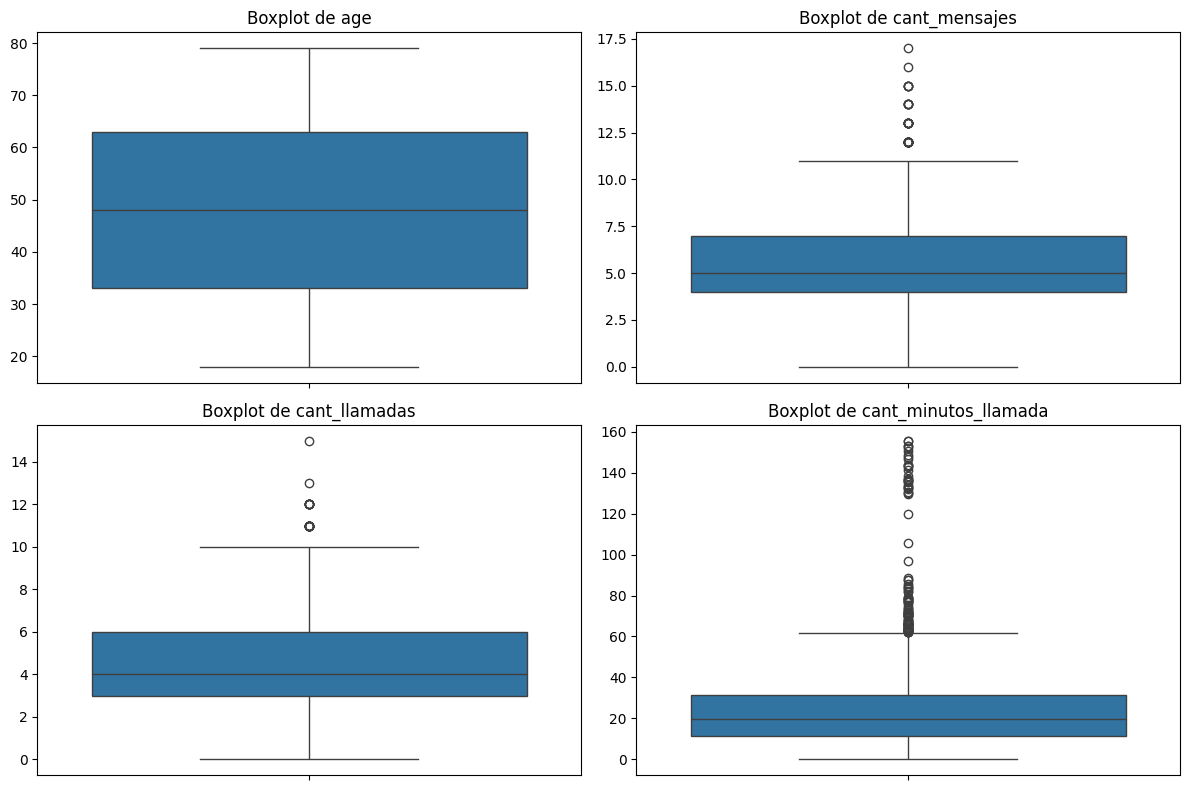

In [51]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, columna in zip(axes, columnas_numericas):
    sns.boxplot(y=user_profile[columna], ax=ax)
    ax.set_title(f'Boxplot de {columna}')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<h3>💡Insights:</h3>

- `age`: sí hay outliers, pero corresponden a valores inválidos como -999 que deben tratarse como datos faltantes antes de cualquier análisis.
- `cant_mensajes`: hay outliers en el extremo superior (12-17 mensajes) según IQR; son pocos usuarios de alto volumen, pero pueden ser parte del comportamiento real y conviene mantenerlos para no perder clientes intensivos.
- `cant_llamadas`: hay outliers altos (11-15 llamadas) según IQR; son responsables de una cola derecha ligera y pueden mantenerse si el objetivo es estudiar uso extremo, aunque con cuidado en modelos sensibles.
- `cant_minutos_llamada`: hay outliers altos (más de 61.86 minutos) según IQR; representan un grupo de consumo elevado que conviene conservar para análisis de usuarios intensivos, siempre que no se trate como error de registro.
</div>

In [52]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
limites_iqr = []
for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    iqr = q3 - q1
    limites_iqr.append({
        'columna': col,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'limite_inferior': q1 - 1.5 * iqr,
        'limite_superior': q3 + 1.5 * iqr,
    })
limites_iqr = pd.DataFrame(limites_iqr)
limites_iqr

,columna,q1,q3,iqr,limite_inferior,limite_superior
0,cant_mensajes,4.0000,7.0000,3.000,-0.50,11.50
1,cant_llamadas,3.0000,6.0000,3.000,-1.50,10.50
2,cant_minutos_llamada,11.1075,31.4125,20.305,-19.35,61.87


In [53]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000


<div class="alert alert-block alert-info">
<h3>💡Insights:</h3>

- `cant_mensajes`: se recomienda mantener los outliers, ya que son pocos usuarios con actividad intensiva y parecen reflejar un comportamiento real más que un error de registro.
- `cant_llamadas`: también conviene mantenerlos como parte del grupo de alto uso, pues representan variabilidad válida en el número de llamadas de algunos clientes.
- `cant_minutos_llamada`: se sugiere preservar estos valores elevados, ya que forman parte de la cola derecha de usuarios con consumo de llamada intenso; solo deben revisarse si se sospecha de un registro incorrecto.
</div>

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [54]:
# Crear columna grupo_uso
uso_total = user_profile['cant_mensajes'] + user_profile['cant_llamadas']
user_profile['grupo_uso'] = pd.cut(
    uso_total,
    bins=[-1, 5, 10, float('inf')],
    labels=['Bajo uso', 'Uso medio', 'Alto uso']
)

In [55]:
# verificar cambios
user_profile[['user_id', 'cant_mensajes', 'cant_llamadas', 'grupo_uso']].sample(10)

,user_id,cant_mensajes,cant_llamadas,grupo_uso
3381,13381,4.0,2.0,Uso medio
3018,13018,4.0,4.0,Uso medio
727,10727,6.0,3.0,Uso medio
1848,11848,6.0,9.0,Alto uso
38,10038,4.0,4.0,Uso medio
1622,11622,7.0,8.0,Alto uso
3895,13895,4.0,4.0,Uso medio
196,10196,8.0,7.0,Alto uso
880,10880,9.0,5.0,Alto uso
816,10816,6.0,3.0,Uso medio


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [56]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = pd.cut(
    user_profile['age'],
    bins=[0, 30, 60, 120],
    labels=['Joven', 'Adulto Joven', 'Adulto Mayor']
)

In [57]:
# verificar cambios
user_profile[['user_id', 'age', 'grupo_edad']].sample(10)

,user_id,age,grupo_edad
3957,13957,24,Joven
2774,12774,73,Adulto Mayor
2279,12279,20,Joven
3195,13195,61,Adulto Mayor
907,10907,25,Joven
3336,13336,38,Adulto Joven
955,10955,27,Joven
690,10690,57,Adulto Joven
3436,13436,76,Adulto Mayor
3419,13419,50,Adulto Joven


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

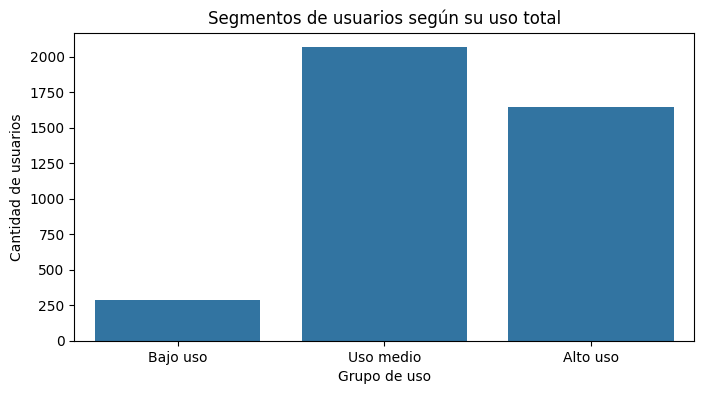

In [58]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 4))
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Segmentos de usuarios según su uso total')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

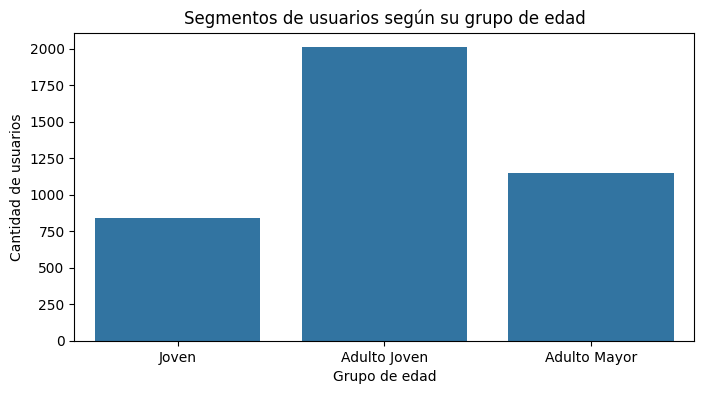

In [59]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 4))
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto Joven', 'Adulto Mayor'])
plt.title('Segmentos de usuarios según su grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

<div class="alert alert-block alert-info">
<h3>Análisis ejecutivo</h3>

⚠️ **Problemas detectados en los datos**
- La columna `age` contenía 55 registros con valor `-999` (≈1.4% de los usuarios), que fueron identificados como datos inválidos y deben tratarse como faltantes o imputarse.
- La columna `city` presentaba 96 registros con valor `?` (≈2.4%), lo que reduce la confianza en cualquier segmentación geográfica basada en esa variable.
- En `usage`, había 50 filas con `date` no convertible a fecha (≈0.12% del dataset de uso), un problema de calidad de registros que afecta análisis temporales.
- Tras la agregación de uso por usuario se detectó 1 cliente sin historial de uso, lo cual puede corresponder a un cliente nuevo o a un registro incompleto.

🔍 **Segmentos por Edad**
- Se identificaron tres grupos: `Joven` (<30), `Adulto Joven` (30-60) y `Adulto Mayor` (>60).
- El segmento más grande es `Adulto Joven` (~49% de los usuarios), seguido de `Adulto Mayor` (~29%) y `Joven` (~21%).
- La distribución por plan es similar entre las categorías de edad, lo que indica que no hay una fuerte diferenciación de edad entre clientes de `Basico` y `Premium`.

📊 **Segmentos por Nivel de Uso**
- La segmentación por uso mostró 289 clientes de `Bajo uso`, 2,066 de `Uso medio` y 1,644 de `Alto uso`.
- El segmento más valioso en términos de potencial de ingresos es `Alto uso`, ya que representa el 41% de la base y consiste en clientes que consumen más minutos y llamadas.
- El plan `Básico` tiene más usuarios de `Alto uso` en valor absoluto que `Premium`, lo que sugiere oportunidades de migración o ajuste de la oferta.

🚨 **Patrones de uso extremo**
- Los outliers reales se observaron en el extremo superior de `cant_mensajes`, `cant_llamadas` y `cant_minutos_llamada`.
- Estos clientes intensivos parecen reflejar un comportamiento legítimo más que errores, por lo que conviene conservarlos en el análisis para no subestimar la demanda de consumo.
- Especialmente los minutos de llamada elevados indican que hay un segmento concreto que podría beneficiarse de paquetes con más minutos o condiciones preferenciales.

💡 **Recomendaciones**
- Mantener los valores extremos en el análisis y diseñar ofertas específicas para los usuarios de `Alto uso`, tanto en mensajes como en llamadas.
- Proponer una migración o plan complementario para clientes `Básico` de alto uso, con mayor capacidad de minutos y mensajes incluidos.
- Fortalecer la calidad de datos en `age` y `city` para mejorar la segmentación futura y evitar decisiones basadas en registros inválidos.
- Revisar las políticas de overage y los costos por minuto extra, especialmente para clientes con minutos de llamada por encima de 60, para reducir el riesgo de churn por facturas inesperadas.
</div>


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`